# TAHAP 1 — Kalibrasi Subsistem Hotel

**Parameter dikalibrasi:** TPK Ambang (0,20–0,35) dan Laju Demolisi Dasar (0,02–0,08).
**Parameter berpasangan:** Sensitivitas Konstruksi terhadap TPK dihitung ulang dengan identitas
stock-flow pada **setiap titik grid**, bukan dikalibrasi.

**Target:** Jumlah Hotel dan Akomodasi. TPK hanya dievaluasi.
**Periode fungsi tujuan:** 2016–2019 dan 2023–2025 (2020–2021 COVID dan 2022 tahun pembukaan kembali dikeluarkan).
**Fungsi tujuan:** J = NRMSE Hotel = RMSE ÷ rata-rata data pada periode tersebut.
**Metode:** grid 31 × 25 = 775 titik, dijalankan untuk file P1 dan P1b.

**Aturan keputusan** dengan himpunan indiferen I = {θ : J(θ) ≤ 1,05 · J_min}:

| Aturan | Kondisi | Keputusan |
|---|---|---|
| R1 | nilai turunan ∈ I | perbaikan tidak material, pertahankan |
| R2 | I menyentuh kedua ujung suatu dimensi | tidak teridentifikasi, pertahankan |
| R3 | optimum di batas rentang | prosedur diagnostik lima langkah |
| R4 | selain itu | adopsi optimum, jika gerbang P1b juga setuju |

Ambang 5% adalah kriteria operasional peneliti; 2% dan 10% dihitung sebagai uji kepekaan keputusan.

In [1]:
!pip install pysd openpyxl matplotlib scipy -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.1/95.1 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 717.0/717.0 kB 18.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.2/150.2 kB 5.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 919.5/919.5 kB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.4/268.4 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 8.9 MB/s eta 0:00:00


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import warnings, time
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt, pysd
from scipy import stats
warnings.filterwarnings("ignore")

FOLDER = Path("/content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi")
FILE_P1  = FOLDER / "Uji Parsial P1 & P4 V2.mdl"
FILE_P1B = FOLDER / "UJI Parsial P1b v2.mdl"

TAHUN = np.arange(2016, 2026)
OBJ   = np.array([2016, 2017, 2018, 2019, 2023, 2024, 2025])
MSK, NONCOVID = np.isin(TAHUN, OBJ), ~np.isin(TAHUN, [2020, 2021])

HOTEL15 = np.array([1165,1170,1179,1617,1817,1848,1696,1818,1820,2000,2291], float)   # 2015-2025
TPK15   = np.array([34.89,37.72,45.08,45.11,45.34,28.90,27.48,44.99,44.77,42.17,38.07])/100
INV15   = np.array([53.0896,373.8424,165.3915,568.3341,741.4483,489.6932,848.8042,463.5886,
                    1175.2552,712.2835,1325.950399])
DATA_HOTEL, DATA_TPK = HOTEL15[1:], TPK15[1:]

## Parameter berpasangan dan statistik

In [4]:
def sens(ambang, demolisi):
    """Identitas stock-flow: (ΔHotel 2015-25 + d·ΣHotel 2015-24) ÷ Σ[Inv·MAX(0, TPK − Ambang)] 2016-25"""
    return ((HOTEL15[-1]-HOTEL15[0]) + demolisi*HOTEL15[:-1].sum()) / \
           np.sum(INV15[1:]*np.maximum(0.0, TPK15[1:]-ambang))

assert abs(sens(0.275, 0.05) - 2.313846) < 1e-4, "cek data: sensitivitas awal harus 2,313846"


def nrmse(sim, act, msk):
    return np.sqrt(np.mean((sim[msk]-act[msk])**2)) / act[msk].mean()


def statistik(sim, act, t):
    e = sim-act; SA, SS, SE = act.std(), sim.std(), e.std()
    r = np.corrcoef(sim, act)[0,1]; mse = np.mean(e**2)
    la, ls = stats.linregress(t, act), stats.linregress(t, sim); n = len(t)
    th = abs(ls.slope-la.slope)/np.sqrt(la.stderr**2+ls.stderr**2); tt = stats.t.ppf(0.975, 2*n-4)
    tren = ("Berlawanan arah" if np.sign(ls.slope) != np.sign(la.slope)
            else ("Berbeda nyata" if th > tt else "Tidak berbeda nyata"))
    return {"Tren":tren, "E1":abs(sim.mean()-act.mean())/abs(act.mean()), "E2":abs(SS-SA)/SA,
            "DC":SE/(SA+SS), "U1":(sim.mean()-act.mean())**2/mse, "U2":(SS-SA)**2/mse,
            "U3":2*(1-r)*SS*SA/mse, "MAPE (%)":100*np.mean(np.abs(e/act))}


def buat(f):
    m = pysd.read_vensim(str(f))
    tpk = [k for k in m.namespace if "TPK" in k and "Ambang" not in k][0]
    return m, tpk


def eval_titik(m, tpk, a, d):
    s = sens(a, d)
    r = m.run(params={"TPK Ambang": a, "Laju Demolisi Dasar": d,
                      "Sensitivitas Konstruksi terhadap TPK": s},
              return_columns=["Jumlah Hotel dan Akomodasi", tpk], return_timestamps=list(TAHUN))
    r = r.apply(lambda x: np.real(x.astype(complex)))
    return r["Jumlah Hotel dan Akomodasi"].values, r[tpk].values, s

## Grid 775 titik untuk P1 dan P1b

In [5]:
AMBANG   = np.round(np.arange(0.20, 0.35001, 0.005), 3)    # 31 nilai
DEMOLISI = np.round(np.arange(0.02, 0.08001, 0.0025), 4)   # 25 nilai

grid, cache = {}, {}
for nama, f in [("P1", FILE_P1), ("P1b", FILE_P1B)]:
    m, tpk = buat(f)
    h0, t0, s0 = eval_titik(m, tpk, 0.275, 0.05)
    print(f"{nama}: titik turunan -> Hotel 2025 {h0[-1]:,.3f} | J {nrmse(h0,DATA_HOTEL,MSK):.5f} | sens {s0:.6f}")
    t0_ = time.time(); baris = []
    for a in AMBANG:
        for d in DEMOLISI:
            h, tp, s = eval_titik(m, tpk, a, d)
            if nama == "P1":
                cache[(a, d)] = h
            baris.append({"TPK Ambang":a, "Laju Demolisi Dasar":d, "Sensitivitas Konstruksi":s,
                          "J (NRMSE Hotel, objektif)":nrmse(h, DATA_HOTEL, MSK),
                          "NRMSE Hotel (tanpa COVID)":nrmse(h, DATA_HOTEL, NONCOVID),
                          "NRMSE TPK (objektif)":nrmse(tp, DATA_TPK, MSK), "Hotel 2025":h[-1]})
    grid[nama] = pd.DataFrame(baris)
    print(f"   {len(baris)} titik dalam {time.time()-t0_:.0f} detik")

P1: titik turunan -> Hotel 2025 2,192.584 | J 0.10415 | sens 2.313846
   775 titik dalam 9 detik
P1b: titik turunan -> Hotel 2025 2,152.072 | J 0.11121 | sens 2.313846
   775 titik dalam 11 detik


## Penerapan aturan keputusan (5% pra-registrasi; 2% dan 10% sebagai uji kepekaan)

In [6]:
hasil = []
for nama, g in grid.items():
    jmin = g["J (NRMSE Hotel, objektif)"].min()
    opt  = g.loc[g["J (NRMSE Hotel, objektif)"].idxmin()]
    jt   = g[(g["TPK Ambang"]==0.275) & (g["Laju Demolisi Dasar"]==0.05)].iloc[0]["J (NRMSE Hotel, objektif)"]
    for amb in [0.02, 0.05, 0.10]:
        I = g[g["J (NRMSE Hotel, objektif)"] <= (1+amb)*jmin]
        di_I = jt <= (1+amb)*jmin
        sentuh_a = I["TPK Ambang"].min()==AMBANG[0] and I["TPK Ambang"].max()==AMBANG[-1]
        sentuh_d = I["Laju Demolisi Dasar"].min()==DEMOLISI[0] and I["Laju Demolisi Dasar"].max()==DEMOLISI[-1]
        di_batas = opt["TPK Ambang"] in (AMBANG[0],AMBANG[-1]) or opt["Laju Demolisi Dasar"] in (DEMOLISI[0],DEMOLISI[-1])
        if di_I:               aturan = "R1 - pertahankan nilai turunan"
        elif sentuh_a or sentuh_d: aturan = "R2 - tidak teridentifikasi, pertahankan"
        elif di_batas:         aturan = "R3 - optimum di batas, prosedur diagnostik"
        else:                  aturan = "R4 - adopsi optimum"
        hasil.append({"File":nama, "Ambang indiferen":f"{amb:.0%}", "J minimum":jmin, "J nilai turunan":jt,
                      "Perbaikan relatif (%)":100*(jt-jmin)/jt, "Titik dalam I":len(I),
                      "Ambang opt":opt["TPK Ambang"], "Demolisi opt":opt["Laju Demolisi Dasar"],
                      "Sensitivitas opt":opt["Sensitivitas Konstruksi"], "Turunan dalam I":bool(di_I),
                      "I menyentuh kedua ujung Ambang":bool(sentuh_a),
                      "I menyentuh kedua ujung Demolisi":bool(sentuh_d), "Keputusan":aturan})

keputusan = pd.DataFrame(hasil)
keputusan[["File","Ambang indiferen","J minimum","J nilai turunan","Perbaikan relatif (%)",
           "Titik dalam I","Ambang opt","Demolisi opt","Keputusan"]].round(5)

,File,Ambang indiferen,J minimum,J nilai turunan,Perbaikan relatif (%),Titik dalam I,Ambang opt,Demolisi opt,Keputusan
0,P1,2%,0.09203,0.10415,11.63540,42,0.35,0.06,"R3 - optimum di batas, prosedur diagnostik"
1,P1,5%,0.09203,0.10415,11.63540,117,0.35,0.06,"R3 - optimum di batas, prosedur diagnostik"
2,P1,10%,0.09203,0.10415,11.63540,283,0.35,0.06,"R2 - tidak teridentifikasi, pertahankan"
3,P1b,2%,0.10577,0.11121,4.88862,97,0.33,0.06,R4 - adopsi optimum
4,P1b,5%,0.10577,0.11121,4.88862,252,0.33,0.06,"R2 - tidak teridentifikasi, pertahankan"
5,P1b,10%,0.10577,0.11121,4.88862,597,0.33,0.06,R1 - pertahankan nilai turunan


## Prosedur diagnostik R3 — leave-one-year-out

Langkah 3 aturan batas: memeriksa apakah optimum di batas digerakkan oleh satu tahun anomali
yang sudah tercatat (lonjakan akomodasi 2018).

In [7]:
print(f"{'Tahun dikeluarkan':<20}{'Ambang opt':>12}{'Demolisi opt':>14}{'J min':>10}{'J turunan':>11}{'Perbaikan %':>13}")
loyo = []
for buang in [None] + list(OBJ):
    th = [t for t in OBJ if t != buang]; msk = np.isin(TAHUN, th)
    best = min(((nrmse(h, DATA_HOTEL, msk), a, d) for (a, d), h in cache.items()))
    jt = nrmse(cache[(0.275, 0.05)], DATA_HOTEL, msk)
    loyo.append({"Tahun dikeluarkan": "(tidak ada)" if buang is None else buang,
                 "Ambang opt":best[1], "Demolisi opt":best[2], "J min":best[0],
                 "J turunan":jt, "Perbaikan (%)":100*(jt-best[0])/jt})
    print(f"{str(loyo[-1]['Tahun dikeluarkan']):<20}{best[1]:>12.3f}{best[2]:>14.4f}{best[0]:>10.5f}{jt:>11.5f}{loyo[-1]['Perbaikan (%)']:>13.2f}")
loyo = pd.DataFrame(loyo)

print("\nResidual pada nilai turunan (simulasi - data):")
h0 = cache[(0.275, 0.05)]
for t, s, d_ in zip(TAHUN, h0, DATA_HOTEL):
    print(f"  {t}: sim {s:8.1f}  data {d_:6.0f}  selisih {s-d_:+8.1f} ({100*(s-d_)/d_:+5.1f}%)")

Tahun dikeluarkan     Ambang opt  Demolisi opt     J min  J turunan  Perbaikan %
(tidak ada)                0.350        0.0600   0.09203    0.10415        11.64
2016                       0.350        0.0600   0.09450    0.10694        11.64
2017                       0.350        0.0625   0.09338    0.10703        12.75
2018                       0.330        0.0550   0.06248    0.07222        13.49
2019                       0.270        0.0200   0.09139    0.09696         5.74
2023                       0.350        0.0425   0.09680    0.11382        14.96
2024                       0.340        0.0775   0.09229    0.10995        16.06
2025                       0.350        0.0650   0.09089    0.11676        22.15

Residual pada nilai turunan (simulasi - data):
  2016: sim   1170.0  data   1170  selisih     +0.0 ( +0.0%)
  2017: sim   1182.7  data   1179  selisih     +3.7 ( +0.3%)
  2018: sim   1260.1  data   1617  selisih   -356.9 (-22.1%)
  2019: sim   1571.9  data   1817  selis

## Perbandingan statistik: nilai turunan vs optimum

In [8]:
m, tpk = buat(FILE_P1)
opt_p1 = keputusan[keputusan.File=="P1"].iloc[0]
rows = []
for lab, a, d in [("Nilai turunan (0,275; 0,05)", 0.275, 0.05),
                  (f"Optimum P1 ({opt_p1['Ambang opt']}; {opt_p1['Demolisi opt']})",
                   float(opt_p1["Ambang opt"]), float(opt_p1["Demolisi opt"]))]:
    h, tp, s = eval_titik(m, tpk, a, d)
    for versi, msk in [("Periode objektif", MSK), ("Tanpa COVID", NONCOVID), ("Dengan COVID", np.ones(10, bool))]:
        rows.append({"Kondisi":lab, "Variabel":"Jumlah Hotel", "Versi":versi,
                     **statistik(h[msk], DATA_HOTEL[msk], TAHUN[msk]), "NRMSE":nrmse(h, DATA_HOTEL, msk)})
        rows.append({"Kondisi":lab, "Variabel":"TPK", "Versi":versi,
                     **statistik(tp[msk], DATA_TPK[msk], TAHUN[msk]), "NRMSE":nrmse(tp, DATA_TPK, msk)})
banding = pd.DataFrame(rows)
banding.round(4)

,Kondisi,Variabel,Versi,Tren,E1,E2,DC,U1,U2,U3,MAPE (%),NRMSE
0,"Nilai turunan (0,275; 0,05)",Jumlah Hotel,Periode objektif,Tidak berbeda nyata,0.0468,0.0672,0.1997,0.2021,0.0211,0.7767,6.8622,0.1041
1,"Nilai turunan (0,275; 0,05)",TPK,Periode objektif,Tidak berbeda nyata,0.1081,2.4214,0.6094,0.2281,0.6235,0.1484,16.6281,0.2263
2,"Nilai turunan (0,275; 0,05)",Jumlah Hotel,Tanpa COVID,Tidak berbeda nyata,0.0402,0.0773,0.2011,0.1728,0.0283,0.7988,6.0480,0.0966
3,"Nilai turunan (0,275; 0,05)",TPK,Tanpa COVID,Tidak berbeda nyata,0.0643,2.5684,0.6692,0.0807,0.6488,0.2705,17.3740,0.2263
4,"Nilai turunan (0,275; 0,05)",Jumlah Hotel,Dengan COVID,Tidak berbeda nyata,0.0089,0.1435,0.2476,0.0078,0.0726,0.9196,7.0997,0.1003
5,"Nilai turunan (0,275; 0,05)",TPK,Dengan COVID,Tidak berbeda nyata,0.0204,1.1513,0.4667,0.0072,0.6085,0.3843,18.7346,0.2398
6,Optimum P1 (0.35; 0.06),Jumlah Hotel,Periode objektif,Tidak berbeda nyata,0.0322,0.0582,0.1858,0.1225,0.0203,0.8572,6.8583,0.0920
7,Optimum P1 (0.35; 0.06),TPK,Periode objektif,Tidak berbeda nyata,0.0905,2.3923,0.6383,0.1607,0.6111,0.2282,15.9623,0.2258
8,Optimum P1 (0.35; 0.06),Jumlah Hotel,Tanpa COVID,Tidak berbeda nyata,0.0128,0.1085,0.2134,0.0180,0.0571,0.9249,7.4262,0.0955
9,Optimum P1 (0.35; 0.06),TPK,Tanpa COVID,Tidak berbeda nyata,0.0390,2.6643,0.7091,0.0268,0.6315,0.3417,17.7514,0.2379


## Grafik permukaan J dan perbandingan deret

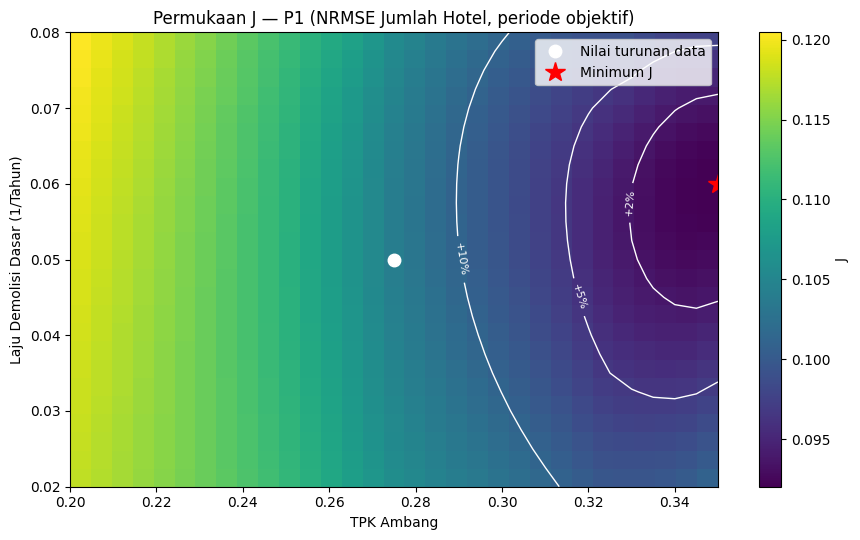

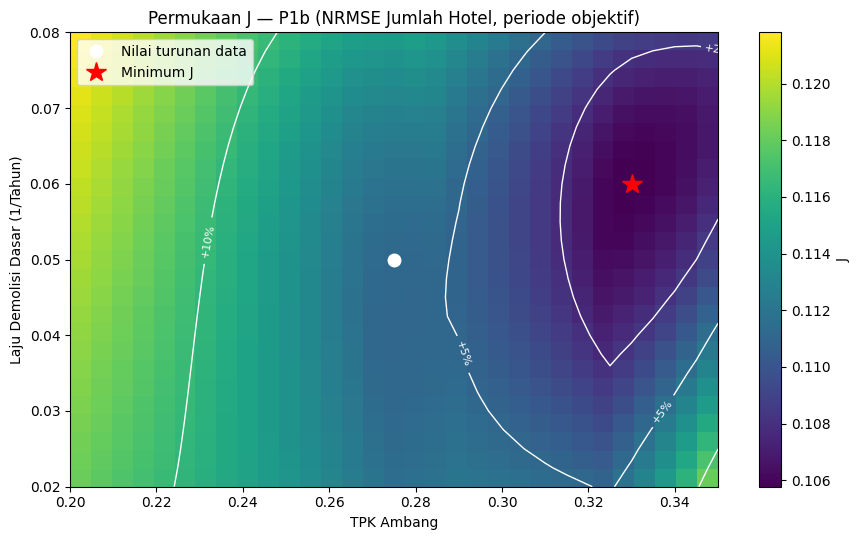

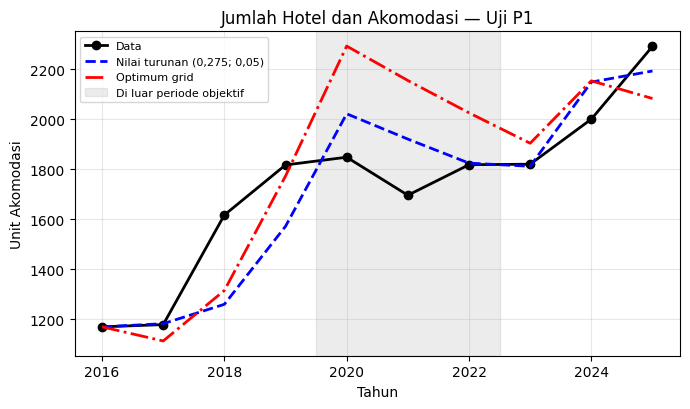

In [9]:
for nama, g in grid.items():
    pv = g.pivot(index="Laju Demolisi Dasar", columns="TPK Ambang", values="J (NRMSE Hotel, objektif)")
    jmin = g["J (NRMSE Hotel, objektif)"].min()
    fig, ax = plt.subplots(figsize=(9, 5.5))
    im = ax.imshow(pv.values, origin="lower", aspect="auto", cmap="viridis",
                   extent=[AMBANG[0], AMBANG[-1], DEMOLISI[0], DEMOLISI[-1]])
    cs = ax.contour(AMBANG, DEMOLISI, pv.values, levels=[1.02*jmin, 1.05*jmin, 1.10*jmin],
                    colors="white", linewidths=1)
    ax.clabel(cs, fmt={1.02*jmin:"+2%", 1.05*jmin:"+5%", 1.10*jmin:"+10%"}, fontsize=8)
    ax.plot(0.275, 0.05, "wo", ms=9, label="Nilai turunan data")
    o = g.loc[g["J (NRMSE Hotel, objektif)"].idxmin()]
    ax.plot(o["TPK Ambang"], o["Laju Demolisi Dasar"], "r*", ms=15, label="Minimum J")
    ax.set_xlabel("TPK Ambang"); ax.set_ylabel("Laju Demolisi Dasar (1/Tahun)")
    ax.set_title(f"Permukaan J — {nama} (NRMSE Jumlah Hotel, periode objektif)")
    fig.colorbar(im, label="J"); ax.legend()
    fig.tight_layout(); fig.savefig(FOLDER / f"tahap1_permukaan_J_{nama}.png", dpi=150); plt.show()

h_opt, _, _ = eval_titik(m, tpk, float(opt_p1["Ambang opt"]), float(opt_p1["Demolisi opt"]))
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(TAHUN, DATA_HOTEL, "ko-", lw=2, label="Data")
ax.plot(TAHUN, cache[(0.275, 0.05)], "b--", lw=2, label="Nilai turunan (0,275; 0,05)")
ax.plot(TAHUN, h_opt, "r-.", lw=2, label="Optimum grid")
ax.axvspan(2019.5, 2022.5, color="grey", alpha=0.15, label="Di luar periode objektif")
ax.set_xlabel("Tahun"); ax.set_ylabel("Unit Akomodasi"); ax.grid(alpha=0.3); ax.legend(fontsize=8)
ax.set_title("Jumlah Hotel dan Akomodasi — Uji P1")
fig.tight_layout(); fig.savefig(FOLDER / "tahap1_hotel.png", dpi=150); plt.show()

## Simpan Excel

In [10]:
berkas = FOLDER / "hasil_kalibrasi_tahap1.xlsx"
with pd.ExcelWriter(berkas) as w:
    keputusan.round(6).to_excel(w, sheet_name="Keputusan", index=False)
    banding.round(6).to_excel(w, sheet_name="Perbandingan Statistik", index=False)
    loyo.round(6).to_excel(w, sheet_name="Diagnostik LOYO", index=False)
    for nama, g in grid.items():
        g.sort_values("J (NRMSE Hotel, objektif)").round(6).to_excel(w, sheet_name=f"Grid {nama}", index=False)
        g.pivot(index="Laju Demolisi Dasar", columns="TPK Ambang",
                values="J (NRMSE Hotel, objektif)").round(6).to_excel(w, sheet_name=f"Permukaan J {nama}")
print("Tersimpan:", berkas)

Tersimpan: /content/drive/MyDrive/Skripsi_Citra/Pengujian Model Sistem Dinamis/[02] Uji Perilaku/Kalibrasi/hasil_kalibrasi_tahap1.xlsx


## Angka untuk pencocokan

- Titik turunan: **J = 0,10415**, Hotel 2025 = 2.192,584, Sensitivitas 2,313846.
- Optimum P1: **Ambang 0,350; Demolisi 0,0600; Sensitivitas 5,059**; J = 0,09203 (perbaikan 11,64%).
- Optimum P1b: Ambang 0,330; Demolisi 0,0600; J = 0,10577 (perbaikan 4,89%).
- Keputusan pada ambang 5%: P1 → **R3** (optimum di batas atas rentang), P1b → **R2**.